In [1]:
# https://www.kaggle.com/datasets/tanavbajaj/yahoo-finance-all-stocks-dataset-daily-update

In [2]:
#!/bin/bash
!curl -L -o yahoo-finance-all-stocks-dataset-daily-update.zip\
  https://www.kaggle.com/api/v1/datasets/download/tanavbajaj/yahoo-finance-all-stocks-dataset-daily-update

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  132M  100  132M    0     0  14.8M      0  0:00:08  0:00:08 --:--:-- 20.2M


In [3]:
!unzip /content/yahoo-finance-all-stocks-dataset-daily-update.zip

Archive:  /content/yahoo-finance-all-stocks-dataset-daily-update.zip
  inflating: A.csv                   
  inflating: AAL.csv                 
  inflating: AAPL.csv                
  inflating: ABBV.csv                
  inflating: ABNB.csv                
  inflating: ABT.csv                 
  inflating: ACGL.csv                
  inflating: ACN.csv                 
  inflating: ADBE.csv                
  inflating: ADI.csv                 
  inflating: ADM.csv                 
  inflating: ADP.csv                 
  inflating: ADSK.csv                
  inflating: AEE.csv                 
  inflating: AEP.csv                 
  inflating: AES.csv                 
  inflating: AFL.csv                 
  inflating: AIG.csv                 
  inflating: AIZ.csv                 
  inflating: AJG.csv                 
  inflating: AKAM.csv                
  inflating: ALB.csv                 
  inflating: ALGN.csv                
  inflating: ALK.csv                 
  inflating: ALL.cs

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_theme(style="darkgrid")

plt.rcParams["figure.figsize"] = (14, 6)

In [6]:
df = pd.read_csv("AAPL.csv")

In [7]:
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1980-12-12 00:00:00-05:00,0.099450,0.099882,0.099450,0.099450,469033600,0.0,0.0
1,1980-12-15 00:00:00-05:00,0.094694,0.094694,0.094261,0.094261,175884800,0.0,0.0
2,1980-12-16 00:00:00-05:00,0.087775,0.087775,0.087343,0.087343,105728000,0.0,0.0
3,1980-12-17 00:00:00-05:00,0.089504,0.089937,0.089504,0.089504,86441600,0.0,0.0
4,1980-12-18 00:00:00-05:00,0.092099,0.092532,0.092099,0.092099,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
10779,2023-09-15 00:00:00-04:00,176.479996,176.500000,173.820007,175.009995,109205100,0.0,0.0
10780,2023-09-18 00:00:00-04:00,176.479996,179.380005,176.169998,177.970001,67257600,0.0,0.0
10781,2023-09-19 00:00:00-04:00,177.520004,179.630005,177.130005,179.070007,51826900,0.0,0.0
10782,2023-09-20 00:00:00-04:00,179.259995,179.699997,175.399994,175.490005,58333200,0.0,0.0


In [8]:
df.shape

(10784, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10784 entries, 0 to 10783
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          10784 non-null  object 
 1   Open          10784 non-null  float64
 2   High          10784 non-null  float64
 3   Low           10784 non-null  float64
 4   Close         10784 non-null  float64
 5   Volume        10784 non-null  int64  
 6   Dividends     10784 non-null  float64
 7   Stock Splits  10784 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 674.1+ KB


In [10]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,10784.0,1.828353e+01,3.959627e+01,0.038483,2.393533e-01,4.141864e-01,1.601756e+01,1.959754e+02
High,10784.0,1.848724e+01,4.004860e+01,0.038483,2.452059e-01,4.206070e-01,1.621071e+01,1.979627e+02
Low,10784.0,1.808688e+01,3.917028e+01,0.038050,2.344039e-01,4.077919e-01,1.586194e+01,1.950166e+02
Close,10784.0,1.829481e+01,3.962713e+01,0.038050,2.407344e-01,4.139828e-01,1.607025e+01,1.961851e+02
Volume,10784.0,3.231961e+08,3.367550e+08,0.000000,1.176843e+08,2.108792e+08,4.032098e+08,7.421641e+09
Dividends,10784.0,6.995145e-04,1.115726e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e-01
Stock Splits,10784.0,1.576409e-03,8.448896e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_461/2394721818.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [13]:
df = df.set_index('Date')
df = df.sort_index()

In [14]:
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1980-12-12 00:00:00-05:00,0.099450,0.099882,0.099450,0.099450,469033600,0.0,0.0
1980-12-15 00:00:00-05:00,0.094694,0.094694,0.094261,0.094261,175884800,0.0,0.0
1980-12-16 00:00:00-05:00,0.087775,0.087775,0.087343,0.087343,105728000,0.0,0.0
1980-12-17 00:00:00-05:00,0.089504,0.089937,0.089504,0.089504,86441600,0.0,0.0
1980-12-18 00:00:00-05:00,0.092099,0.092532,0.092099,0.092099,73449600,0.0,0.0


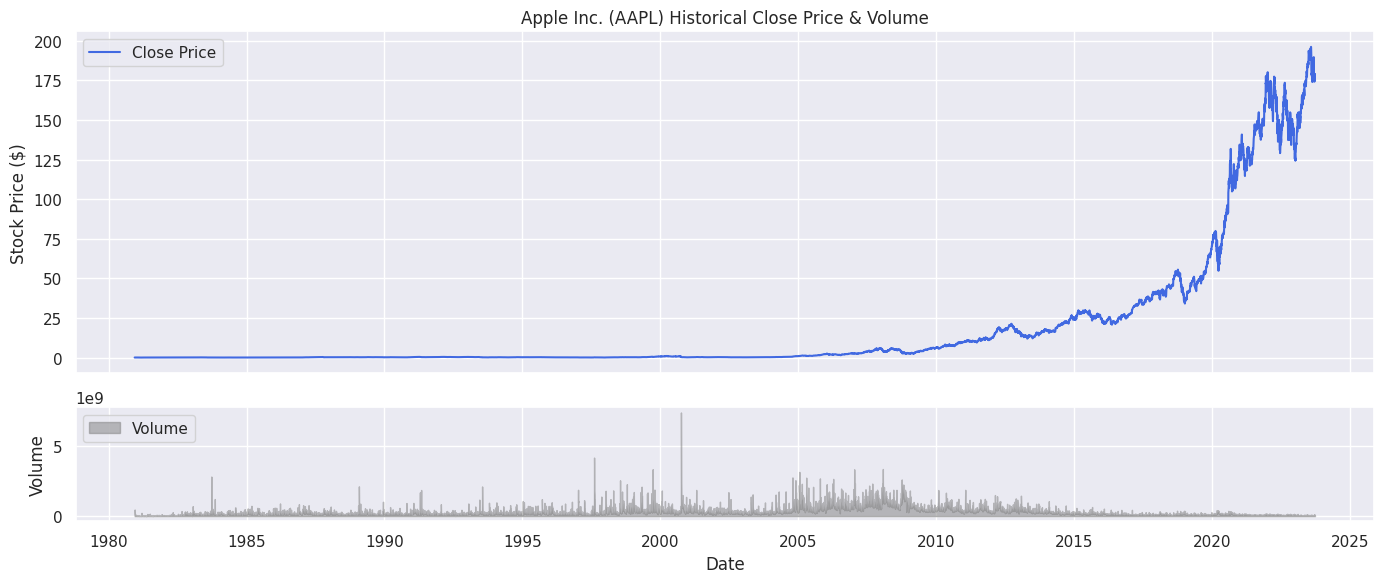

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df.index, df['Close'], color='royalblue', label='Close Price')
ax1.set_ylabel('Stock Price ($)')
ax1.set_title('Apple Inc. (AAPL) Historical Close Price & Volume')
ax1.legend(loc='upper left')

ax2.fill_between(df.index, df['Volume'], color='gray', alpha=0.5, label='Volume')
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [16]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

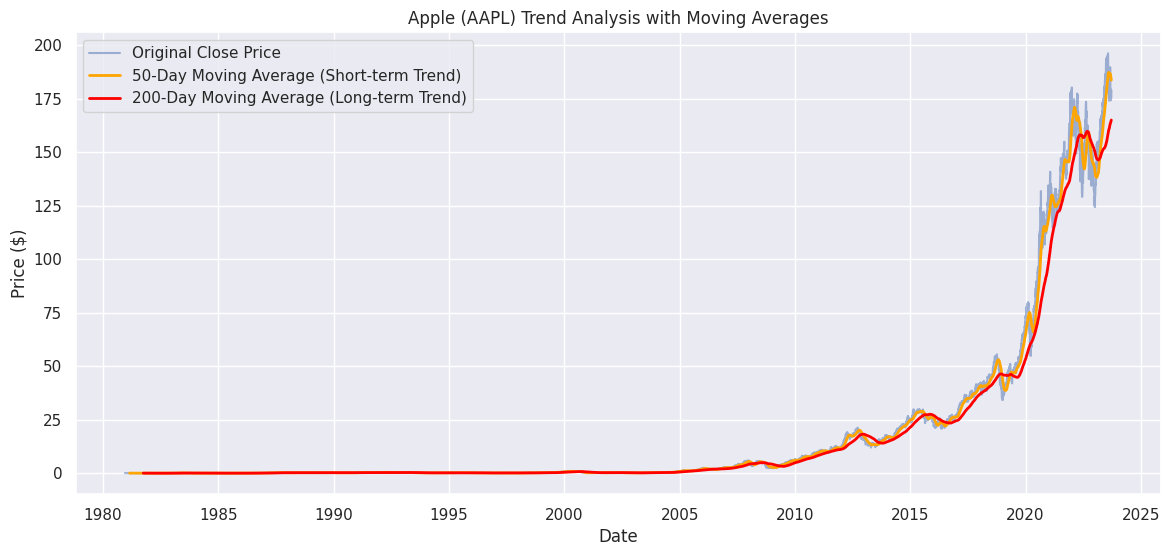

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df['Close'], label='Original Close Price', alpha=0.5)
plt.plot(df.index, df['MA50'], label='50-Day Moving Average (Short-term Trend)', color='orange', linewidth=2)
plt.plot(df.index, df['MA200'], label='200-Day Moving Average (Long-term Trend)', color='red', linewidth=2)
plt.title('Apple (AAPL) Trend Analysis with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')

plt.legend()
plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler

In [21]:
data = df[['Close']].copy()

In [22]:
train_size = int(len(data) * 0.80)

train_data = data.iloc[:train_size]

test_data = data.iloc[train_size:]

In [24]:
train_data.shape

(8627, 1)

In [25]:
test_data.shape

(2157, 1)

In [26]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)

test_scaled = scaler.transform(test_data)

In [27]:
def create_sliding_windows(dataset, time_steps=60):

    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

In [30]:
TIME_STEPS = 60

X_train, y_train = create_sliding_windows(train_scaled, time_steps=TIME_STEPS)

In [31]:
X_train.shape

(8567, 60)

In [32]:
y_train.shape

(8567,)

In [33]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [34]:
X_train.shape

(8567, 60, 1)

In [35]:
inputs = np.vstack((train_scaled[-TIME_STEPS:], test_scaled))

X_test, y_test = create_sliding_windows(inputs, time_steps=TIME_STEPS)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [36]:
X_test.shape

(2157, 60, 1)

In [37]:
y_test.shape

(2157,)

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [39]:
model = Sequential()

In [41]:
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

In [43]:
model.add(Dense(units=1))

In [44]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
EPOCHS = 35
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Epoch 1/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - loss: 2.4777e-04 - val_loss: 0.0032
Epoch 2/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 1.0057e-04 - val_loss: 0.0011
Epoch 3/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - loss: 8.3650e-05 - val_loss: 6.8666e-04
Epoch 4/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 7.4107e-05 - val_loss: 0.0014
Epoch 5/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 8.2186e-05 - val_loss: 4.5143e-04
Epoch 6/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 6.9020e-05 - val_loss: 8.4118e-04
Epoch 7/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - loss: 6.1589e-05 - val_loss: 5.4101e-04
Epoch 8/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 7.1645e-05 - val_loss: 8.7029e-04
Epoch 9/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 6.8119e-05 - val_loss: 8.2041e-04
Epoch 10/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 7.4229e-05 - val_loss: 0.0075
Epoch 11/35
241/241 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step 

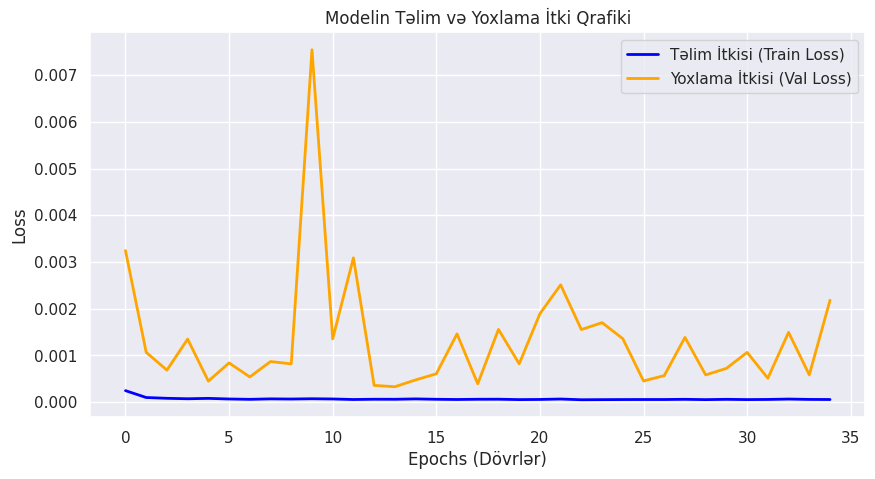

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Təlim İtkisi (Train Loss)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Yoxlama İtkisi (Val Loss)', color='orange', linewidth=2)

plt.title('Modelin Təlim və Yoxlama İtki Qrafiki')
plt.xlabel('Epochs (Dövrlər)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [49]:
predictions_scaled = model.predict(X_test)

68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step


In [50]:
predictions = scaler.inverse_transform(predictions_scaled)

In [51]:
y_test_reshaped = y_test.reshape(-1, 1)
real_prices = scaler.inverse_transform(y_test_reshaped)

In [52]:
mae = mean_absolute_error(real_prices, predictions)
mse = mean_squared_error(real_prices, predictions)
rmse = np.sqrt(mse)

In [53]:
mae

47.708773837135965

In [54]:
mse

4763.853086351544

In [56]:
rmse

np.float64(69.0206714423407)

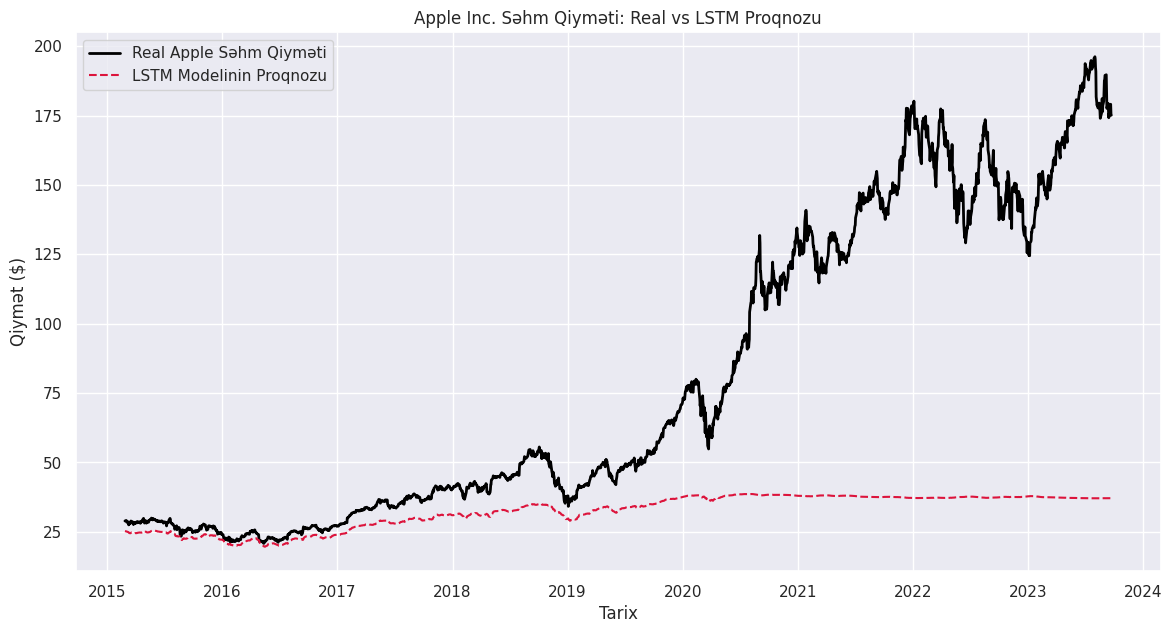

In [57]:
test_dates = test_data.index

plt.figure(figsize=(14, 7))
plt.plot(test_dates, real_prices, color='black', label='Real Apple Səhm Qiyməti', linewidth=2)
plt.plot(test_dates, predictions, color='crimson', label='LSTM Modelinin Proqnozu', linestyle='--')

plt.title('Apple Inc. Səhm Qiyməti: Real vs LSTM Proqnozu')
plt.xlabel('Tarix')
plt.ylabel('Qiymət ($)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()